In [83]:
#import statements
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt2
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import PredictionErrorDisplay



In [3]:
df1 = pd.read_csv('firstrealFinal.csv', usecols=[0,1,2,3,4])
df2 = pd.read_csv('secondrealFinal.csv', usecols=[0,1,2,3,4])
cols =  ["time", "rsp", "ppg", "ecg","eda"]
df1.columns = cols
df2.columns = cols
print(df1.head())
print(df2.head())

arr1 = df1.to_numpy()
arr2 = df2.to_numpy()


     time      rsp       ppg       ecg       eda
0  0.0005  5.32043 -0.014343 -0.004730 -0.004578
1  0.0010  5.32104 -0.014648 -0.004883 -0.003052
2  0.0015  5.31982 -0.014648 -0.004730 -0.003052
3  0.0020  5.32013 -0.014648 -0.004883 -0.004578
4  0.0025  5.32013 -0.014648 -0.004883 -0.004578
     time      rsp       ppg       ecg           eda
0  0.0005  6.25854  0.336914  0.058289  1.526070e-03
1  0.0010  6.25854  0.336304  0.059357  1.526070e-03
2  0.0015  6.25885  0.333862  0.060272  1.526070e-03
3  0.0020  6.25885  0.332336  0.060883  3.051940e-03
4  0.0025  6.25885  0.332031  0.060730  1.862670e-07


In [4]:
arr1time = arr1[:,0]
arr1rsp = arr1[:,1]
arr1ppg = arr1[:,2]
arr1ecg = arr1[:,3]
arr1eda = arr1[:,4]

arr2time = arr2[:,0]
arr2rsp = arr2[:,1]
arr2ppg = arr2[:,2]
arr2ecg = arr2[:,3]
arr2eda = arr2[:,4]

print(arr1time)
print(arr2time)

[5.00000e-04 1.00000e-03 1.50000e-03 ... 1.63326e+02 1.63327e+02
 1.63327e+02]
[5.00000e-04 1.00000e-03 1.50000e-03 ... 1.64798e+02 1.64799e+02
 1.64799e+02]


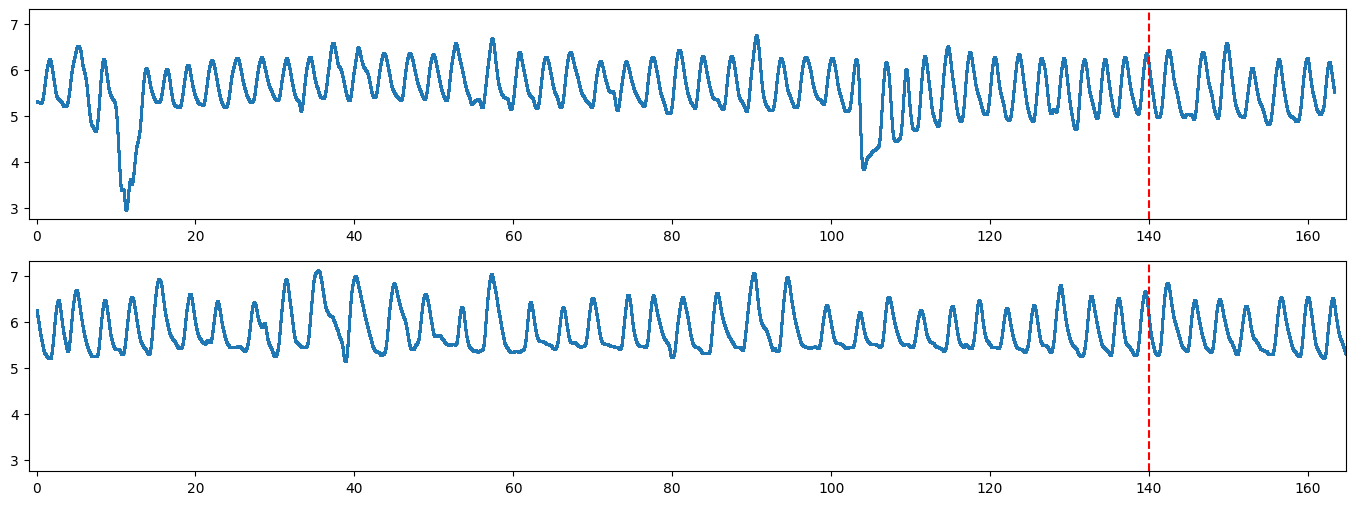

In [5]:
ymin = min(arr1rsp.min(), arr2rsp.min()) - 0.2
ymax = max(arr1rsp.max(), arr2rsp.max()) +0.2

plt.figure(figsize=(17, 6))

plt.subplot(2, 1, 1)
plt.scatter(arr1time, arr1rsp, s=1)
plt.ylim(ymin, ymax)
plt.xlim(-1, max(arr1time.max(), arr2time.max()))
plt.axvline(x=140, color='r', linestyle='--')


plt.subplot(2, 1, 2)
plt.scatter(arr2time, arr2rsp, s=1)
plt.ylim(ymin, ymax)
plt.xlim(-1, max(arr1time.max(), arr2time.max()))
plt.axvline(x=140, color='r', linestyle='--')

plt.show()

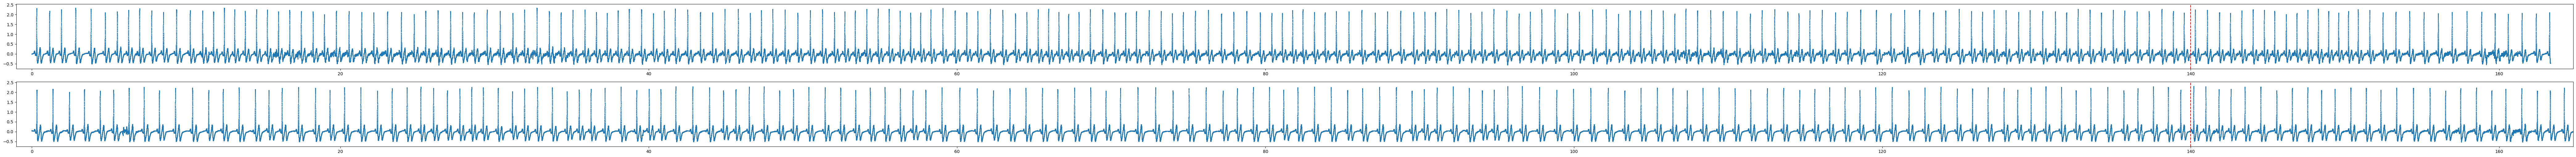

In [15]:
ymin = min(arr1ecg.min(), arr2ecg.min()) - 0.2
ymax = max(arr1ecg.max(), arr2ecg.max()) +0.2

plt.figure(figsize=(107, 6))

plt.subplot(2, 1, 1)
plt.scatter(arr1time, arr1ecg, s=1)
plt.ylim(ymin, ymax)
plt.xlim(-1, max(arr1time.max(), arr2time.max()))
plt.axvline(x=140, color='r', linestyle='--')


plt.subplot(2, 1, 2)
plt.scatter(arr2time, arr2ecg, s=1)
plt.ylim(ymin, ymax)
plt.xlim(-1, max(arr1time.max(), arr2time.max()))
plt.axvline(x=140, color='r', linestyle='--')

plt.show()

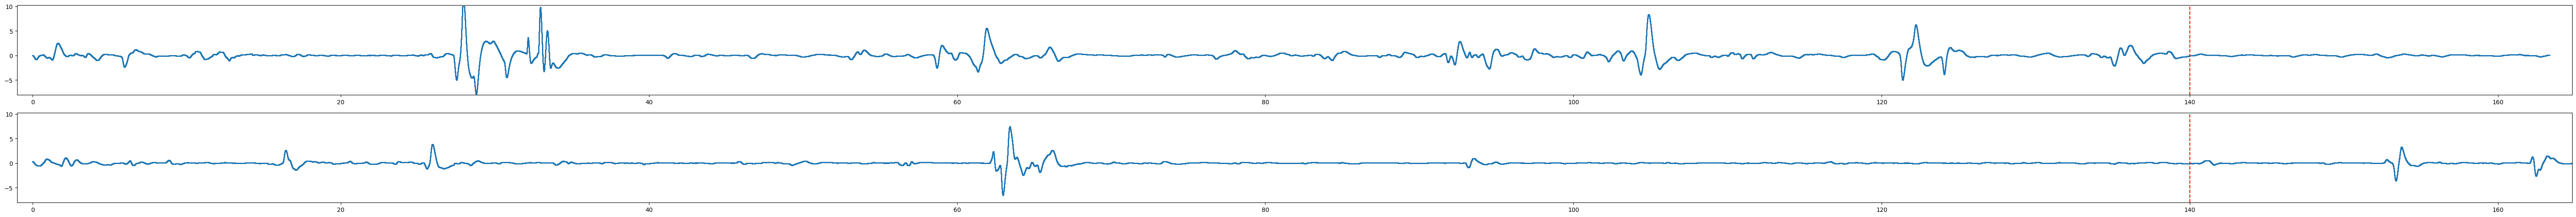

In [36]:
ymin = min(arr1ppg.min(), arr2ppg.min()) - 0.2
ymax = max(arr1ppg.max(), arr2ppg.max()) +0.2

plt.figure(figsize=(77, 6))

plt.subplot(2, 1, 1)
plt.scatter(arr1time, arr1ppg, s=1)
plt.ylim(ymin, ymax)
plt.xlim(-1, max(arr1time.max(), arr2time.max()))
plt.axvline(x=140, color='r', linestyle='--')


plt.subplot(2, 1, 2)
plt.scatter(arr2time, arr2ppg, s=1)
plt.ylim(ymin, ymax)
plt.xlim(-1, max(arr1time.max(), arr2time.max()))
plt.axvline(x=140, color='r', linestyle='--')

plt.show()

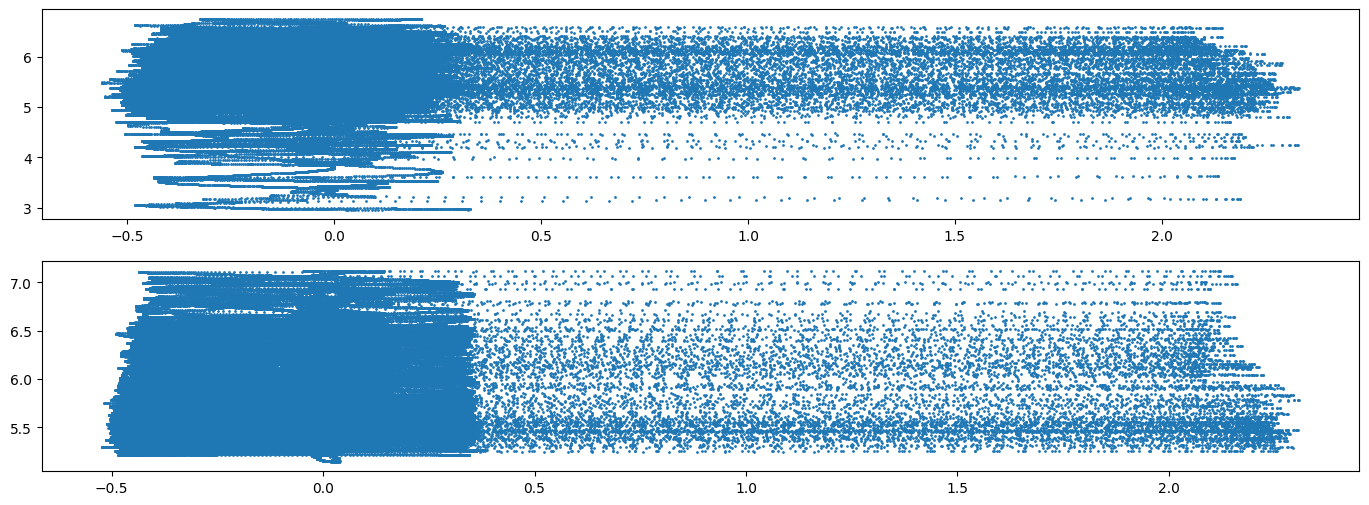

In [11]:
plt.figure(figsize=(17, 6))
plt.subplot(2, 1, 1)
plt.scatter(arr1ecg, arr1rsp, label='First Real', s=1)
plt.subplot(2, 1, 2)
plt.scatter(arr2ecg, arr2rsp, label='Second Real', s=1)

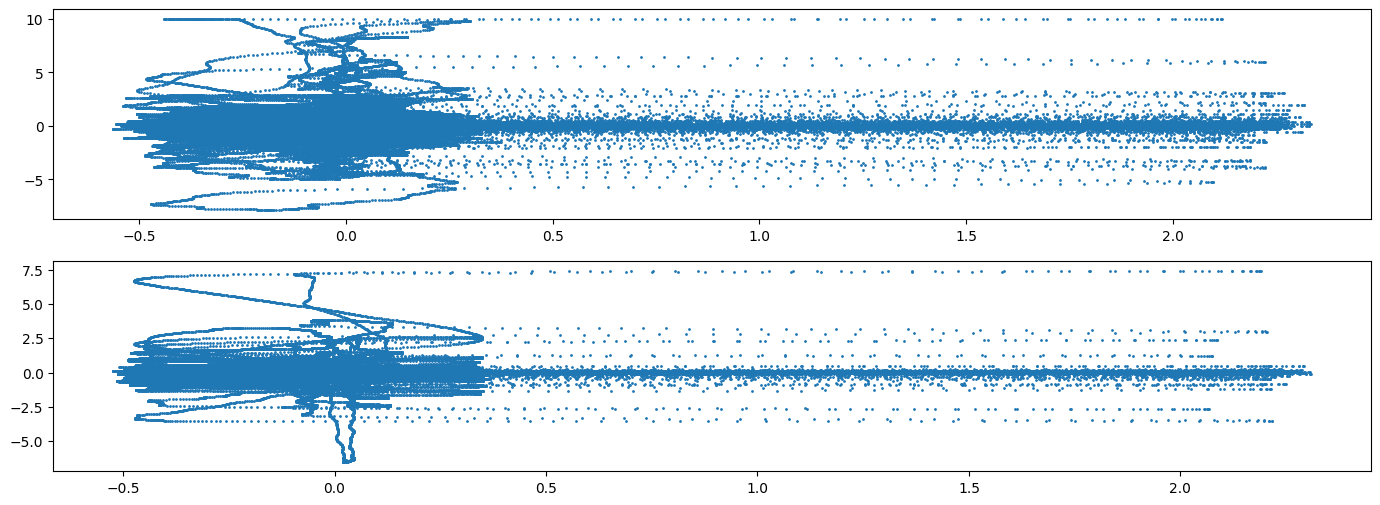

In [12]:
plt.figure(figsize=(17, 6))
plt.subplot(2, 1, 1)
plt.scatter(arr1ecg, arr1ppg, label='First Real', s=1)
plt.subplot(2, 1, 2)
plt.scatter(arr2ecg, arr2ppg, label='Second Real', s=1)

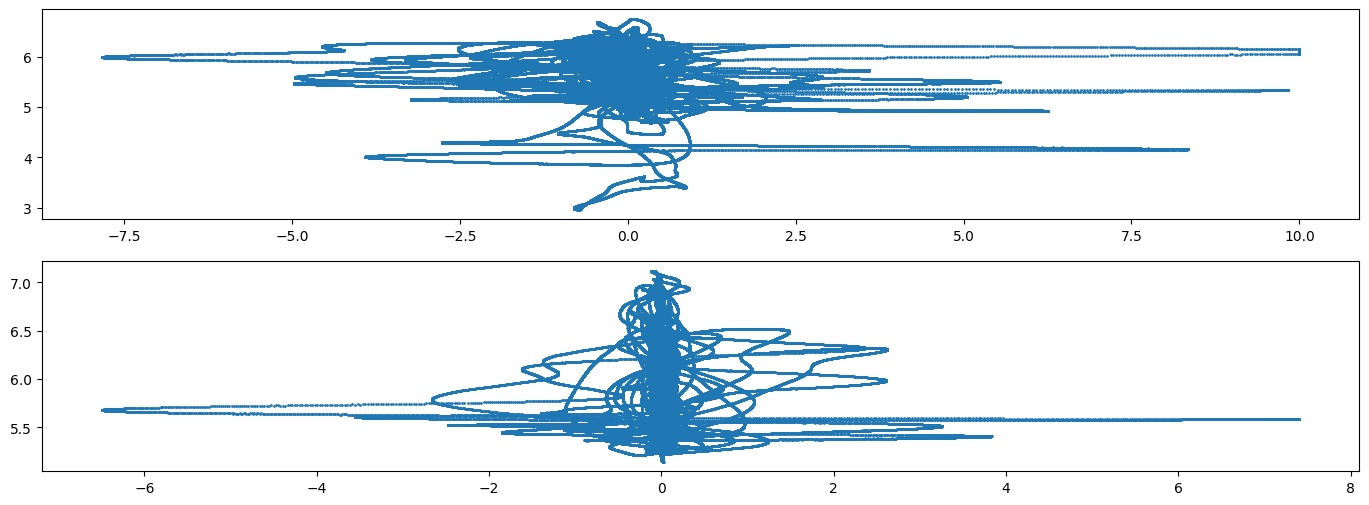

In [13]:
plt.figure(figsize=(17, 6))
plt.subplot(2, 1, 1)
plt.scatter(arr1ppg, arr1rsp, label='First Real', s=1)
plt.subplot(2, 1, 2)
plt.scatter(arr2ppg, arr2rsp, label='Second Real', s=1)

In [14]:
arrecg = np.concatenate((arr1ecg, arr2ecg))
arrppg = np.concatenate((arr1ppg, arr2ppg))
arrrsp = np.concatenate((arr1rsp, arr2rsp))

In [100]:
X = np.stack((arrecg, arrrsp))
print(X)
Y = arrppg
print(Y)

xtrain, xtest, ytrain, ytest = train_test_split(X.T, Y, test_size=0.1, random_state=None)

[[-4.73022e-03 -4.88281e-03 -4.73022e-03 ...  1.02234e-02  1.17493e-02
   1.23596e-02]
 [ 5.32043e+00  5.32104e+00  5.31982e+00 ...  5.30151e+00  5.30090e+00
   5.30151e+00]]
[-0.0143433 -0.0146484 -0.0146484 ... -0.0335693 -0.0338745 -0.0341797]


In [101]:
regr = linear_model.LinearRegression()
regr.fit(xtrain, ytrain)
print(xtest[0:1])
print(regr.predict(xtest[0:1]))

[[0.0241089 5.22858  ]]
[0.09388409]


In [92]:
def checkValidity(ecg, rsp, ppg):
    pred = regr.predict([[ecg, rsp]])
    print(pred)
    if abs(pred - ppg) < 0.1:
        return 1
    else:
        return 0

In [93]:
correct = 0
for i in range(xtest.shape[0]):
    correct += checkValidity(xtest[i][0], xtest[i][1], ytest[i])


[-0.04017987]
[0.06176406]
[-0.00246898]
[0.04638544]
[-0.06724071]
[0.04628681]
[-0.02821827]
[0.02948504]
[0.13835492]
[0.05827408]
[-0.01676137]
[-0.05244853]
[0.0479195]
[0.02995604]
[0.05899362]
[0.01512395]
[-0.08251517]
[0.28910617]
[0.10988563]
[0.07407297]
[-0.00649185]
[-0.04035699]
[-0.03986583]
[0.02587547]
[-0.06801941]
[0.07628707]
[0.00862892]
[0.0251881]
[0.13764798]
[0.06617628]
[0.26336089]
[0.05036954]
[-0.02622858]
[0.0117786]
[-0.06846631]
[0.0748721]
[-0.0514755]
[0.14051049]
[-0.14963618]
[-0.11993984]
[0.05572815]
[0.2182742]
[-0.00113706]
[-0.01707154]
[-0.18537834]
[0.05233235]
[-0.03891431]
[-0.01351871]
[-0.02207508]
[-0.066204]
[0.10560188]
[-0.13898321]
[-0.00343162]
[0.02540601]
[-0.04419357]
[-0.02014201]
[-0.06414716]
[0.14931301]
[-0.03055554]
[0.01026093]
[0.11413193]
[0.03788674]
[0.03119495]
[0.09606662]
[-0.09795785]
[-0.11982342]
[0.06440258]
[0.07571084]
[0.02346186]
[-0.10957646]
[0.05830471]
[0.11594767]
[-0.08723677]
[0.0361809]
[0.13474792]
[

In [94]:
print(correct/xtest.shape[0])

0.5160454697833176


[ 0.0184524  -0.14747601]


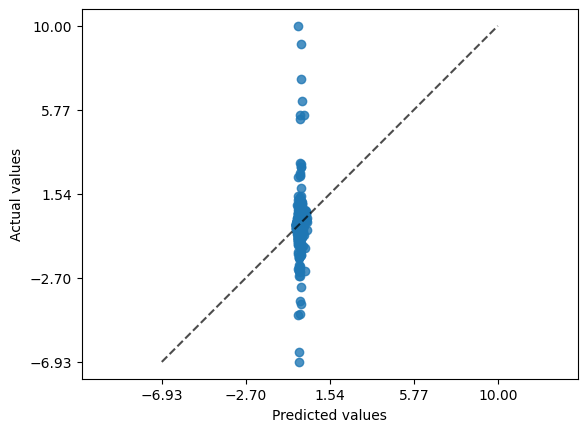

In [99]:
print(regr.coef_)
PredictionErrorDisplay.from_predictions(y_true=ytest, y_pred=regr.predict(xtest), kind='actual_vs_predicted')
plt.show()

In [96]:
r2 = r2_score(ytest, regr.predict(xtest))
mse = mean_squared_error(ytest, regr.predict(xtest))
rmse = np.sqrt(mse)
mae = mean_absolute_error(ytest, regr.predict(xtest))
print("R2 Score: ", r2)
print("MSE: ", mse)
print("RMSE: ", rmse)
print("MAE: ", mae)

print(ytest.min(), ytest.max())
print(ytest.std())

R2 Score:  0.008088368215503072
MSE:  0.6303217369793631
RMSE:  0.7939280426961647
MAE:  0.3137299984084485
-7.8244 9.99969
0.7971584436356816


In [97]:
errors = np.abs(regr.predict(xtest) - ytest)

print("Within 0.1:", np.mean(errors <= 0.1))
print("Median error:", np.median(errors))
print("Mean error:", np.mean(errors))
print("95th percentile:", np.percentile(errors, 95))
print("Max error:", np.max(errors))


r = np.corrcoef(ytest, regr.predict(xtest))[0, 1]
print("Correlation coefficient (r):", r)

Within 0.1: 0.5160454697833176
Median error: 0.09505278881892834
Mean error: 0.3137299984084485
95th percentile: 1.375309208311446
Max error: 10.046167798730224
Correlation coefficient (r): 0.0900755236772853
